# Dividend Gap Closure and Pre-Dividend Run-Up on MOEX

Analysis of two dividend-related effects on Moscow Exchange stocks:
1. Gap closure  does the ex-dividend price drop recover over time?
2. Pre-dividend run-up do stocks appreciate before the record date due to retail demand?

Data: MOEX ISS dividends + daily OHLC for ~100 liquid stocks, 2022-2026.

In [17]:
# Setup: imports, cost assumptions, quick sanity check on SBER dividends.
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy import stats
import time
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from data_cache import get_stocks, get_dividends, RU_UNIVERSE_100

# Transaction costs (Trader tariff)
COMMISSION_PCT = 0.0005
SLIPPAGE_PCT = 0.0008
TOTAL_COST_PCT = (COMMISSION_PCT + SLIPPAGE_PCT) * 2

sber_div = get_dividends(["SBER"], verbose=False)
print(f"SBER dividends (first 10):")
display(sber_div.head(10))

SBER dividends (first 10):


,secid,isin,registryclosedate,value,currencyid
0,SBER,RU0009029540,2019-06-13,16.00,RUB
1,SBER,RU0009029540,2020-10-05,18.70,RUB
2,SBER,RU0009029540,2021-05-12,18.70,RUB
3,SBER,RU0009029540,2023-05-11,25.00,RUB
4,SBER,RU0009029540,2024-07-11,33.30,RUB
5,SBER,RU0009029540,2025-07-18,34.84,RUB


In [18]:
# Download dividends for the full universe and filter to RUB-denominated positive payouts.
all_divs = get_dividends(RU_UNIVERSE_100, verbose=True)

all_divs = all_divs[all_divs["currencyid"] == "RUB"]
all_divs = all_divs[all_divs["value"] > 0]
all_divs["year"] = all_divs["registryclosedate"].dt.year

print(f"\nTotal after filtering: {len(all_divs)} events across {all_divs['secid'].nunique()} tickers")

print(f"\nBy year:")
print(all_divs.groupby("year").size())
print(f"\nBy ticker (top-15 by number of payouts):")
print(all_divs["secid"].value_counts().head(15))

  Скачиваю дивиденды для 18 тикеров...

Total after filtering: 882 events across 87 tickers

By year:
year
2013     13
2014     39
2015     42
2016     50
2017     50
2018     69
2019    112
2020     98
2021     94
2022     65
2023     85
2024     97
2025     68
dtype: int64

By ticker (top-15 by number of payouts):
secid
PHOR     45
CHMF     32
NLMK     29
LKOH     25
MGNT     24
TATNP    23
MAGN     23
TATN     22
GMKN     21
AKRN     20
ROSN     19
KAZT     15
KAZTP    15
NVTK     14
ALRS     14
Name: count, dtype: int64


In [ ]:
# Load daily OHLC prices for the universe.
print("Loading daily candles...")
stocks_d = get_stocks(RU_UNIVERSE_100, interval=24, start="2022-01-01", verbose=False)
stocks_d["date"] = stocks_d["timestamp"].dt.date
print(f"Loaded: {len(stocks_d)} daily candles for {stocks_d['ticker'].nunique()} tickers")

prices_d = stocks_d.pivot_table(index="date", columns="ticker", values="close", aggfunc="last")
prices_d.index = pd.to_datetime(prices_d.index)
print(f"Date range: {prices_d.index.min().date()} -- {prices_d.index.max().date()}")

In [19]:
# Match each dividend event to prices, accounting for T+2 (pre-Aug 2023) vs T+1 settlement.
T1_DATE = pd.Timestamp("2023-08-01")

opens_d = stocks_d.pivot_table(index="date", columns="ticker", values="open", aggfunc="first")
opens_d.index = pd.to_datetime(opens_d.index)

def find_prev_trading_day(date, prices_index, n=1):
    candidates = prices_index[prices_index < date]
    if len(candidates) < n:
        return None
    return candidates[-n]


events = []
for _, row in all_divs.iterrows():
    ticker    = row["secid"]
    rcd       = row["registryclosedate"]
    div_value = row["value"]

    if ticker not in prices_d.columns:
        continue

    if rcd >= T1_DATE:
        next_trading = prices_d.index[prices_d.index >= rcd]
        if next_trading.empty:
            continue
        ex_day   = next_trading[0]
        prev_day = find_prev_trading_day(ex_day, prices_d.index, n=1)
    else:
        ex_day   = find_prev_trading_day(rcd, prices_d.index, n=1)
        prev_day = find_prev_trading_day(rcd, prices_d.index, n=2)

    if ex_day is None or prev_day is None:
        continue

    price_pre      = prices_d.at[prev_day, ticker] if prev_day in prices_d.index else np.nan
    price_open_ex  = opens_d.at[ex_day, ticker]    if ex_day  in opens_d.index  else np.nan
    price_close_ex = prices_d.at[ex_day, ticker]   if ex_day  in prices_d.index else np.nan

    if pd.isna(price_pre) or pd.isna(price_open_ex):
        continue

    gap_actual      = (price_pre - price_open_ex) / price_pre
    gap_theoretical = div_value / price_pre

    events.append({
        "ticker":             ticker,
        "registryclosedate":  rcd,
        "settlement":         "T+1" if rcd >= T1_DATE else "T+2",
        "prev_day":           prev_day,
        "ex_day":             ex_day,
        "price_pre":          price_pre,
        "price_open_ex":      price_open_ex,
        "price_close_ex":     price_close_ex,
        "div_value":          div_value,
        "gap_actual":         gap_actual,
        "gap_theoretical":    gap_theoretical,
        "gap_efficiency":     gap_actual / gap_theoretical if gap_theoretical > 0 else np.nan,
    })

events_df = pd.DataFrame(events)
events_df = events_df.dropna(subset=["gap_actual", "gap_theoretical"])

# Filter outliers: remove events with theoretical gap > 30% (data errors from splits).
n_before = len(events_df)
events_df = events_df[
    (events_df["gap_theoretical"] > 0.001) &
    (events_df["gap_theoretical"] < 0.30)
]
print(f"Outliers removed: {n_before - len(events_df)} events (gap_theoretical > 30%)")

print(f"\nDividend events with price data: {len(events_df)}")
print(f"Unique tickers: {events_df['ticker'].nunique()}")
print(f"\nBy settlement mode:")
print(events_df.groupby("settlement").size())

print(f"\nTheoretical gap stats (% of price):")
print((events_df["gap_theoretical"] * 100).describe().round(2))
print(f"\nActual gap stats (% of price):")
print((events_df["gap_actual"] * 100).describe().round(2))
print(f"\nGap efficiency (1.0 = perfect, <1 = market underreacts):")
eff = events_df["gap_efficiency"].replace([np.inf, -np.inf], np.nan).dropna()
print(eff.describe().round(3))

Outliers removed: 12 events (gap_theoretical > 30%)

Dividend events with price data: 275
Unique tickers: 72

By settlement mode:
settlement
T+1    158
T+2    117
dtype: int64

Theoretical gap stats (% of price):
count    275.00
mean       6.06
std        4.55
min        0.37
25%        2.50
50%        4.87
75%        8.58
max       28.14
Name: gap_theoretical, dtype: float64

Actual gap stats (% of price):
count    275.00
mean       4.17
std        3.95
min       -3.95
25%        0.53
50%        3.34
75%        7.23
max       24.03
Name: gap_actual, dtype: float64

Gap efficiency (1.0 = perfect, <1 = market underreacts):
count    275.000
mean       0.665
std        0.591
min       -2.117
25%        0.288
50%        0.812
75%        0.933
max        4.800
Name: gap_efficiency, dtype: float64


In [20]:
# Compute gap recovery ratio and post-ex-date returns at multiple horizons.
def get_price_after_n_days(ex_day, ticker, n_days, prices_df):
    future_dates = prices_df.index[prices_df.index >= ex_day]
    if len(future_dates) <= n_days:
        return None
    target_date = future_dates[n_days]
    val = prices_df.at[target_date, ticker]
    return val if not pd.isna(val) else None


HORIZONS = [1, 3, 5, 10, 20, 40, 60, 90]

for h in HORIZONS:
    events_df[f"price_d{h}"] = events_df.apply(
        lambda r: get_price_after_n_days(r["ex_day"], r["ticker"], h, prices_d),
        axis=1
    )
    events_df[f"ret_d{h}"] = (events_df[f"price_d{h}"] - events_df["price_open_ex"]) / events_df["price_open_ex"]
    gap_rub = events_df["price_pre"] - events_df["price_open_ex"]
    events_df[f"recovery_d{h}"] = (events_df[f"price_d{h}"] - events_df["price_open_ex"]) / gap_rub

print("Mean gap recovery and mean return from ex-day open:")
summary = []
for h in HORIZONS:
    rec = events_df[f"recovery_d{h}"].dropna()
    ret = events_df[f"ret_d{h}"].dropna()
    if len(rec) < 5:
        continue
    summary.append({
        "horizon_d": h,
        "n_events": len(rec),
        "mean_recovery": rec.mean(),
        "median_recovery": rec.median(),
        "share_closed_pct": (rec >= 1.0).mean() * 100,
        "mean_ret_pct": ret.mean() * 100,
        "median_ret_pct": ret.median() * 100,
        "winrate_pct": (ret > 0).mean() * 100,
    })

summary_df = pd.DataFrame(summary)
display(summary_df.round(3))

Mean gap recovery and mean return from ex-day open:


,horizon_d,n_events,mean_recovery,median_recovery,share_closed_pct,mean_ret_pct,median_ret_pct,winrate_pct
0,1,274,NaN,-0.147,14.599,-0.743,-0.434,40.511
1,3,274,NaN,-0.249,16.423,-0.744,-0.561,43.431
2,5,273,NaN,-0.239,18.315,-0.897,-0.481,44.689
3,10,275,NaN,-0.209,25.818,-0.139,-0.613,45.818
4,20,274,NaN,-0.207,27.372,0.706,-0.120,49.635
5,40,275,NaN,-0.254,34.182,1.653,0.768,51.273
6,60,273,NaN,-0.393,31.502,3.590,0.078,50.183
7,90,275,NaN,-0.392,37.091,4.154,-1.065,48.000


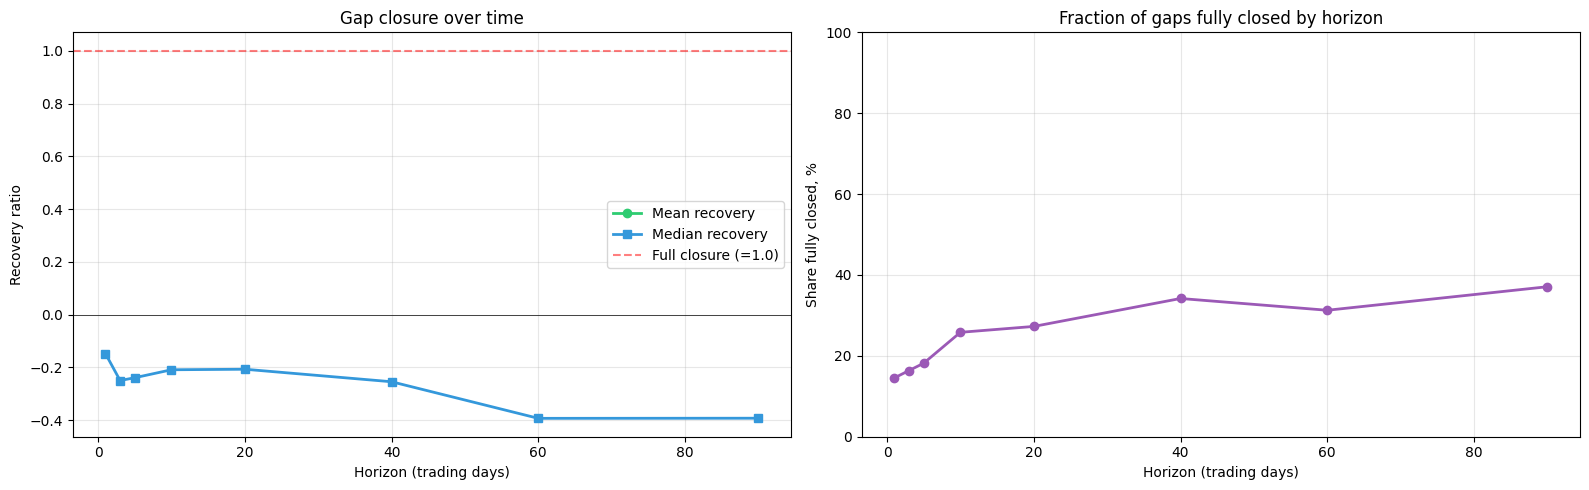

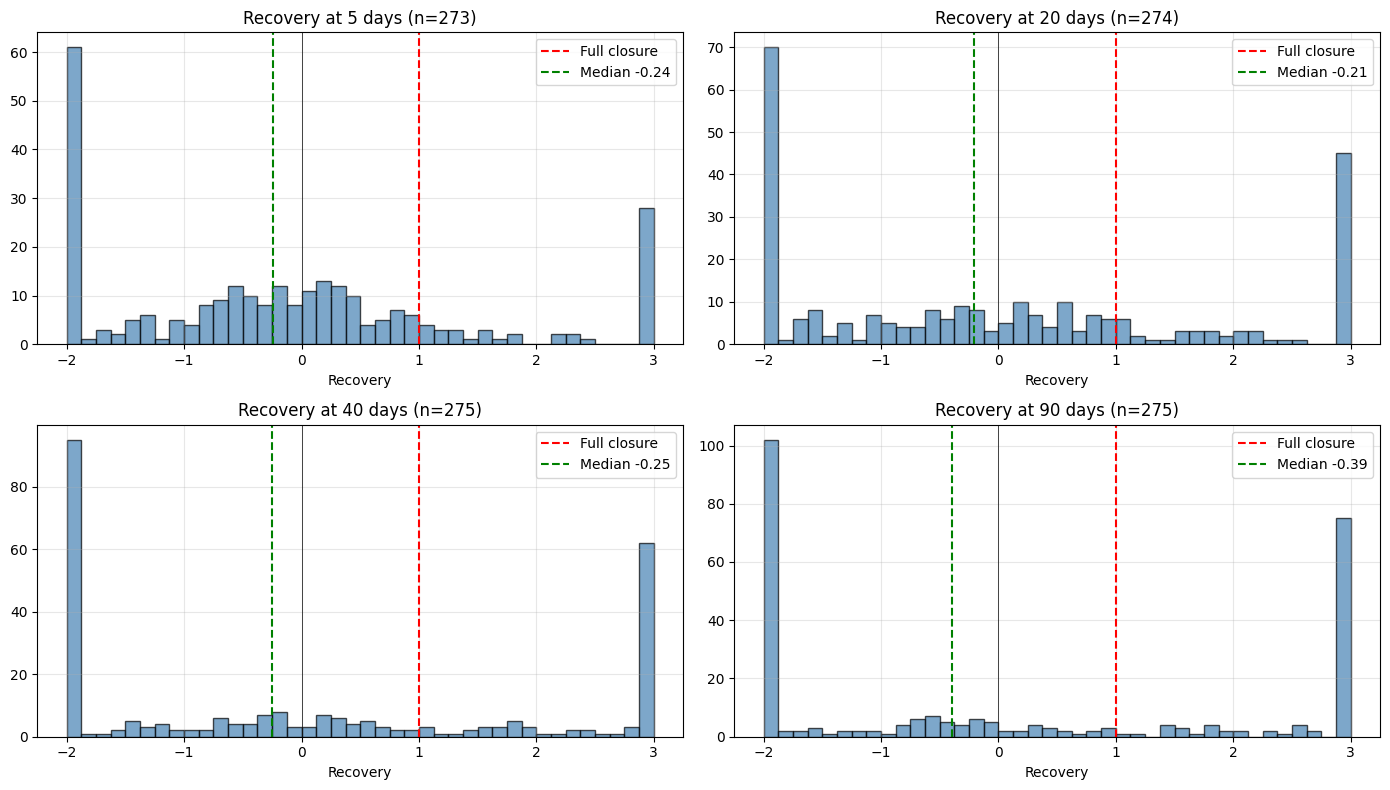

In [21]:
# Visualize gap recovery over time and recovery distributions at selected horizons.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mean_rec = [events_df[f"recovery_d{h}"].mean() for h in HORIZONS]
median_rec = [events_df[f"recovery_d{h}"].median() for h in HORIZONS]
share_closed = [(events_df[f"recovery_d{h}"] >= 1.0).mean() * 100 for h in HORIZONS]

ax = axes[0]
ax.plot(HORIZONS, mean_rec, "o-", color="#2ecc71", linewidth=2, label="Mean recovery")
ax.plot(HORIZONS, median_rec, "s-", color="#3498db", linewidth=2, label="Median recovery")
ax.axhline(1.0, color="red", linestyle="--", alpha=0.5, label="Full closure (=1.0)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Horizon (trading days)")
ax.set_ylabel("Recovery ratio")
ax.set_title("Gap closure over time")
ax.legend()

ax = axes[1]
ax.plot(HORIZONS, share_closed, "o-", color="#9b59b6", linewidth=2)
ax.set_xlabel("Horizon (trading days)")
ax.set_ylabel("Share fully closed, %")
ax.set_title("Fraction of gaps fully closed by horizon")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, h in zip(axes.flat, [5, 20, 40, 90]):
    data = events_df[f"recovery_d{h}"].dropna()
    ax.hist(data.clip(-2, 3), bins=40, color="steelblue", alpha=0.7, edgecolor="black")
    ax.axvline(1.0, color="red", linestyle="--", label="Full closure")
    ax.axvline(data.median(), color="green", linestyle="--", label=f"Median {data.median():.2f}")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"Recovery at {h} days (n={len(data)})")
    ax.set_xlabel("Recovery")
    ax.legend()

plt.tight_layout()
plt.show()

In [22]:
# Breakdown by ticker and by gap size quintile at the 40-day horizon.
TARGET_HORIZON = 40
ticker_stats = events_df.dropna(subset=[f"ret_d{TARGET_HORIZON}"]).groupby("ticker").agg(
    n_events=("ticker", "count"),
    avg_div_yield=("gap_theoretical", lambda x: x.mean() * 100),
    avg_recovery=(f"recovery_d{TARGET_HORIZON}", "mean"),
    median_recovery=(f"recovery_d{TARGET_HORIZON}", "median"),
    avg_ret_pct=(f"ret_d{TARGET_HORIZON}", lambda x: x.mean() * 100),
    winrate_pct=(f"ret_d{TARGET_HORIZON}", lambda x: (x > 0).mean() * 100),
)
ticker_stats = ticker_stats[ticker_stats["n_events"] >= 2].sort_values("avg_ret_pct", ascending=False)

print(f"Top-15 tickers by return {TARGET_HORIZON}d after ex-date:")
display(ticker_stats.head(15).round(3))

print(f"\nWorst-10 (gap does NOT close):")
display(ticker_stats.tail(10).round(3))

print(f"\n--- Dependence on gap size ---")
events_df["gap_size_pct"] = events_df["gap_theoretical"] * 100
events_df["gap_q"] = pd.qcut(events_df["gap_size_pct"], 5,
                              labels=["Q1 (small)", "Q2", "Q3", "Q4", "Q5 (large)"])

gap_quintile = events_df.groupby("gap_q").agg(
    n=("gap_size_pct", "count"),
    gap_mean_pct=("gap_size_pct", "mean"),
    rec_d20=(f"recovery_d20", "mean"),
    rec_d40=(f"recovery_d40", "mean"),
    ret_d20_pct=(f"ret_d20", lambda x: x.mean() * 100),
    ret_d40_pct=(f"ret_d40", lambda x: x.mean() * 100),
    winrate_d40_pct=(f"ret_d40", lambda x: (x > 0).mean() * 100),
).round(3)
display(gap_quintile)

Top-15 tickers by return 40d after ex-date:


,n_events,avg_div_yield,avg_recovery,median_recovery,avg_ret_pct,winrate_pct
ticker,,,,,,
SFIN,4,7.937,4.962,4.016,24.856,100.000
NMTP,3,8.806,3.959,0.639,24.523,100.000
WUSH,2,3.021,14.298,14.298,24.361,100.000
LSNG,5,3.183,-31.000,-1.257,21.666,60.000
SMLT,2,1.805,21.505,21.505,18.139,100.000
MRKV,3,5.987,1.292,-0.720,12.252,33.333
GAZP,2,27.143,39.847,39.847,10.547,50.000
HYDR,3,9.903,-3.347,1.855,9.890,100.000
AKRN,2,2.240,-6.629,-6.629,9.775,50.000



Worst-10 (gap does NOT close):


,n_events,avg_div_yield,avg_recovery,median_recovery,avg_ret_pct,winrate_pct
ticker,,,,,,
BANEP,3,13.223,-0.623,-0.235,-8.997,33.333
RTKM,4,6.247,-1.701,-1.617,-9.350,25.000
LSRG,3,9.203,-0.860,-0.696,-9.450,33.333
VRSBP,3,4.807,-1.476,-1.929,-9.928,33.333
RTKMP,4,7.586,-1.230,-1.191,-10.020,25.000
SVCB,2,4.514,-2.112,-2.112,-10.551,0.000
SELG,4,5.409,-inf,-1.836,-11.627,25.000
AFKS,2,2.328,-4.813,-4.813,-11.941,50.000
ALRS,3,4.075,-inf,-7.869,-12.368,0.000



--- Dependence on gap size ---


,n,gap_mean_pct,rec_d20,rec_d40,ret_d20_pct,ret_d40_pct,winrate_d40_pct
gap_q,,,,,,,
Q1 (small),55,1.413,NaN,NaN,4.881,6.196,56.364
Q2,55,3.023,-inf,NaN,-0.024,-0.752,50.909
Q3,55,4.877,NaN,-inf,0.733,3.768,54.545
Q4,55,7.874,-1.037,-3.407,-0.151,-0.741,47.273
Q5 (large),55,13.113,inf,inf,-1.833,-0.206,47.273


In [23]:
# Backtest: buy at ex-day open, sell after N days; sweep hold period and min gap filters.
def backtest_div_gap(events_df, hold_days=20, min_gap_pct=None,
                      tickers_filter=None, cost_pct=TOTAL_COST_PCT):
    df = events_df.copy()

    if min_gap_pct is not None:
        df = df[df["gap_theoretical"] * 100 >= min_gap_pct]
    if tickers_filter is not None:
        df = df[df["ticker"].isin(tickers_filter)]

    col = f"ret_d{hold_days}"
    if col not in df.columns:
        return None

    df = df.dropna(subset=[col]).copy()
    df["pnl_net"] = df[col] - cost_pct

    if df.empty:
        return None

    n = len(df)
    wins = (df["pnl_net"] > 0).sum()
    avg_pnl = df["pnl_net"].mean()

    df["year"] = pd.to_datetime(df["ex_day"]).dt.year
    yearly_ret = df.groupby("year")["pnl_net"].sum()

    return {
        "trades": n,
        "winrate_pct": wins / n * 100,
        "avg_pnl_pct": avg_pnl * 100,
        "median_pnl_pct": df["pnl_net"].median() * 100,
        "total_ret_pct": df["pnl_net"].sum() * 100,
        "best_year_pct": yearly_ret.max() * 100 if len(yearly_ret) > 0 else 0,
        "worst_year_pct": yearly_ret.min() * 100 if len(yearly_ret) > 0 else 0,
    }


configs_results = []
for hold in [5, 10, 20, 40, 60, 90]:
    for min_gap in [None, 1.0, 2.0, 3.0, 5.0]:
        m = backtest_div_gap(events_df, hold_days=hold, min_gap_pct=min_gap)
        if m is None or m["trades"] < 10:
            continue
        m["hold_days"] = hold
        m["min_gap_pct"] = min_gap if min_gap is not None else 0
        configs_results.append(m)

configs_results_df = pd.DataFrame(configs_results)
configs_results_df = configs_results_df.sort_values("avg_pnl_pct", ascending=False)
print(f"Top-15 configurations by avg PnL per trade:")
display(configs_results_df.head(15).round(3))

print(f"\nWorst-5:")
display(configs_results_df.tail(5).round(3))

Top-15 configurations by avg PnL per trade:


,trades,winrate_pct,avg_pnl_pct,median_pnl_pct,total_ret_pct,best_year_pct,worst_year_pct,hold_days,min_gap_pct
25,275,47.636,3.894,-1.325,1070.867,2041.164,-613.284,90,0.0
26,261,46.743,3.398,-1.468,886.766,1822.399,-582.477,90,1.0
20,273,47.985,3.330,-0.182,909.152,1787.818,-544.033,60,0.0
28,192,44.792,3.117,-2.086,598.413,1446.392,-498.975,90,3.0
21,259,48.263,2.938,-0.182,761.011,1604.077,-507.750,60,1.0
27,230,46.522,2.774,-1.584,638.111,1563.183,-570.391,90,2.0
23,190,45.789,2.474,-1.058,469.972,1196.866,-419.348,60,3.0
22,228,46.930,2.160,-0.993,492.382,1343.485,-530.653,60,2.0
29,132,43.939,1.990,-2.086,262.629,847.857,-337.684,90,5.0
15,275,50.545,1.393,0.508,383.093,890.767,-654.567,40,0.0



Worst-5:


,trades,winrate_pct,avg_pnl_pct,median_pnl_pct,total_ret_pct,best_year_pct,worst_year_pct,hold_days,min_gap_pct
8,192,38.021,-1.415,-1.401,-271.669,38.368,-197.743,10,3.0
2,230,42.174,-1.534,-0.845,-352.795,13.852,-167.160,5,2.0
9,132,40.152,-1.575,-1.797,-207.879,45.127,-136.465,10,5.0
3,192,40.104,-1.852,-1.221,-355.574,12.988,-191.767,5,3.0
4,132,40.909,-2.168,-1.758,-286.237,19.255,-139.100,5,5.0


In [24]:
# Walk-forward validation: select "good" tickers using only past data to avoid look-ahead bias.
good_tickers = ticker_stats[ticker_stats["median_recovery"] > 0.5].index.tolist()
print(f"Good tickers (median recovery > 0.5): {len(good_tickers)}")
print(f"  {good_tickers}")

print(f"\n--- Backtest on good tickers only ---")
for hold in [10, 20, 40, 60]:
    m = backtest_div_gap(events_df, hold_days=hold, min_gap_pct=1.0,
                          tickers_filter=good_tickers)
    if m and m["trades"] >= 5:
        print(f"  hold={hold}, gap>=1%: {m['trades']} trades, "
              f"winrate={m['winrate_pct']:.1f}%, "
              f"avg PnL={m['avg_pnl_pct']:+.2f}%, "
              f"total={m['total_ret_pct']:+.1f}%")

print(f"\n--- Walk-forward (anti-overfit) ---")

events_sorted = events_df.sort_values("ex_day").reset_index(drop=True)
wf_trades = []

for i, ev in events_sorted.iterrows():
    if i < 30:
        continue

    history = events_sorted.iloc[:i].dropna(subset=["recovery_d40"])
    if history.empty:
        continue

    hist_stats = history.groupby("ticker").agg(
        n=("ticker", "count"),
        med_rec=("recovery_d40", "median"),
    )
    hist_stats = hist_stats[hist_stats["n"] >= 2]
    good = hist_stats[hist_stats["med_rec"] > 0.5].index.tolist()

    if ev["ticker"] not in good:
        continue
    if ev["gap_theoretical"] * 100 < 1.0:
        continue
    if pd.isna(ev.get("ret_d40")):
        continue

    wf_trades.append({
        "date": ev["ex_day"],
        "ticker": ev["ticker"],
        "gap_pct": ev["gap_theoretical"] * 100,
        "ret_pct": ev["ret_d40"] * 100,
        "pnl_net_pct": (ev["ret_d40"] - TOTAL_COST_PCT) * 100,
    })

wf_df = pd.DataFrame(wf_trades)
if not wf_df.empty:
    print(f"WF trades: {len(wf_df)}")
    print(f"  Winrate: {(wf_df['pnl_net_pct'] > 0).mean() * 100:.1f}%")
    print(f"  Avg PnL: {wf_df['pnl_net_pct'].mean():+.2f}%")
    print(f"  Median PnL: {wf_df['pnl_net_pct'].median():+.2f}%")
    print(f"  Total: {wf_df['pnl_net_pct'].sum():+.1f}%")
else:
    print("No WF trades")

Good tickers (median recovery > 0.5): 22
  ['SFIN', 'NMTP', 'WUSH', 'SMLT', 'GAZP', 'HYDR', 'NKNCP', 'TGKA', 'MRKU', 'KMAZ', 'MOEX', 'MDMG', 'POSI', 'ROSN', 'BELU', 'ABRD', 'T', 'MRKC', 'OGKB', 'MGNT', 'SNGS', 'NLMK']

--- Backtest on good tickers only ---
  hold=10, gap>=1%: 76 trades, winrate=48.7%, avg PnL=-0.28%, total=-21.1%
  hold=20, gap>=1%: 76 trades, winrate=55.3%, avg PnL=+2.14%, total=+162.6%
  hold=40, gap>=1%: 76 trades, winrate=67.1%, avg PnL=+6.86%, total=+521.4%
  hold=60, gap>=1%: 75 trades, winrate=53.3%, avg PnL=+6.70%, total=+502.2%

--- Walk-forward (anti-overfit) ---
WF trades: 53
  Winrate: 49.1%
  Avg PnL: +1.22%
  Median PnL: -0.02%
  Total: +64.6%


In [25]:
# Pre-dividend run-up: buy N days before ex-date, sell on the last cum-dividend day, benchmark vs IMOEX.
from data_cache import get_index, MOEX_INDEX

imoex = get_index(MOEX_INDEX, interval=24, start="2022-01-01", verbose=False)
imoex_prices = imoex.set_index(pd.to_datetime(imoex["timestamp"].dt.date))["close"]

trading_days = prices_d.index

def build_offset_map(trading_days, n):
    arr = trading_days
    return {arr[i]: arr[i - n] for i in range(n, len(arr))}

ENTRY_WINDOWS = [5, 10, 20, 30, 40, 60]
offset_maps = {n: build_offset_map(trading_days, n) for n in ENTRY_WINDOWS}

records = []
for _, ev in events_df.iterrows():
    ex_day     = ev["ex_day"]
    prev_day   = ev["prev_day"]
    ticker     = ev["ticker"]
    price_exit = ev["price_pre"]

    if pd.isna(price_exit):
        continue

    imoex_exit = imoex_prices.asof(prev_day)

    for n in ENTRY_WINDOWS:
        entry_date = offset_maps[n].get(ex_day)
        if entry_date is None:
            continue

        price_entry = prices_d.at[entry_date, ticker] if ticker in prices_d.columns else np.nan
        if pd.isna(price_entry) or price_entry == 0:
            continue

        raw_ret = price_exit / price_entry - 1
        net_ret = raw_ret - TOTAL_COST_PCT

        imoex_entry = imoex_prices.asof(entry_date)
        mkt_ret = (imoex_exit / imoex_entry - 1
                   if not pd.isna(imoex_entry) and imoex_entry > 0 else np.nan)
        alpha = net_ret - mkt_ret if not pd.isna(mkt_ret) else np.nan

        records.append({
            "entry_days": n,
            "ticker":     ticker,
            "entry_date": entry_date,
            "exit_date":  prev_day,
            "gap_pct":    ev["gap_theoretical"] * 100,
            "net_ret":    net_ret,
            "mkt_ret":    mkt_ret,
            "alpha":      alpha,
        })

trades_all = pd.DataFrame(records)

summary_rows = []
for n, grp in trades_all.groupby("entry_days"):
    a = grp["alpha"].dropna()
    t = a.mean() / a.std() * np.sqrt(len(a)) if len(a) > 1 else np.nan
    summary_rows.append({
        "entry_days_before": n,
        "n_trades":          len(grp),
        "avg_net_ret_%":     grp["net_ret"].mean() * 100,
        "med_net_ret_%":     grp["net_ret"].median() * 100,
        "avg_mkt_ret_%":     grp["mkt_ret"].mean() * 100,
        "avg_alpha_%":       a.mean() * 100,
        "med_alpha_%":       a.median() * 100,
        "winrate_%":         (grp["net_ret"] > 0).mean() * 100,
        "alpha_winrate_%":   (a > 0).mean() * 100,
        "t_stat":            t,
    })

summary_pre = pd.DataFrame(summary_rows)
print("Pre-Dividend Run-Up summary by entry window")
print("alpha = net_ret minus IMOEX return over the same period\n")
display(summary_pre.round(3))

Pre-Dividend Run-Up summary by entry window
alpha = net_ret minus IMOEX return over the same period



,entry_days_before,n_trades,avg_net_ret_%,med_net_ret_%,avg_mkt_ret_%,avg_alpha_%,med_alpha_%,winrate_%,alpha_winrate_%,t_stat
0,5,269,-0.802,-0.647,-0.142,-0.660,-0.240,39.777,44.981,-3.038
1,10,269,-0.068,-0.062,-0.876,0.808,0.885,49.071,56.506,2.752
2,20,265,1.421,1.168,-1.145,2.566,2.184,56.226,64.151,5.371
3,30,266,3.837,0.904,-1.850,5.687,4.213,54.135,66.165,6.955
4,40,262,6.539,2.314,-1.855,8.394,5.511,57.252,67.939,7.405
5,60,262,8.149,2.032,-2.538,10.688,6.920,56.870,70.611,7.515


Best window: 60 days before ex-date

Trades: 262
Avg alpha: +10.69%
Median alpha: +6.92%
Alpha winrate: 71%
t-stat alpha: 7.51

Alpha by year:
      count  mean_pct
year                 
2022     64     20.13
2023     72     14.97
2024     89      2.15
2025     37      6.57


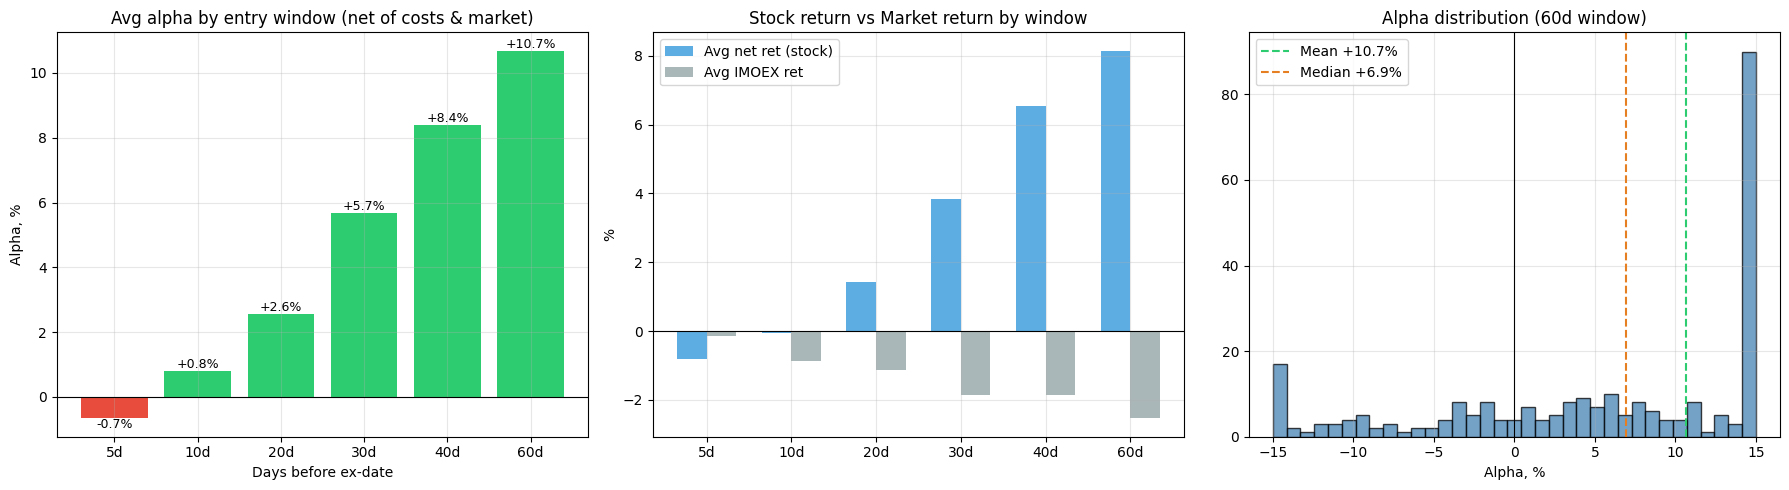


Tickers by alpha, 60d before ex-date (>=2 events):


,avg_alpha_%,med_alpha_%,n
ticker,,,
TGKN,61.11,14.41,5
VRSBP,50.98,14.66,3
MRKU,46.38,50.18,4
BSPB,33.62,37.16,5
LSRG,30.05,41.66,3
...,...,...,...
ASTR,-5.20,-3.69,3
ALRS,-5.90,-7.81,3
NKNC,-7.07,-3.83,4


In [26]:
# Detailed analysis of the best entry window and per-ticker alpha breakdown.
best_n = int(summary_pre.loc[summary_pre["avg_alpha_%"].idxmax(), "entry_days_before"])
print(f"Best window: {best_n} days before ex-date\n")

best_trades = trades_all[trades_all["entry_days"] == best_n].copy()
best_trades["year"] = pd.to_datetime(best_trades["entry_date"]).dt.year

print(f"Trades: {len(best_trades)}")
print(f"Avg alpha: {best_trades['alpha'].mean()*100:+.2f}%")
print(f"Median alpha: {best_trades['alpha'].median()*100:+.2f}%")
print(f"Alpha winrate: {(best_trades['alpha'] > 0).mean()*100:.0f}%")
print(f"t-stat alpha: {best_trades['alpha'].mean() / best_trades['alpha'].std() * np.sqrt(len(best_trades)):.2f}")

yearly = best_trades.groupby("year")["alpha"].agg(["mean", "count"])
yearly["mean_pct"] = yearly["mean"] * 100
print(f"\nAlpha by year:")
print(yearly[["count", "mean_pct"]].round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_bar = ["#2ecc71" if v > 0 else "#e74c3c"
              for v in summary_pre["avg_alpha_%"]]
axes[0].bar(summary_pre["entry_days_before"].astype(str) + "d",
            summary_pre["avg_alpha_%"], color=colors_bar)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Avg alpha by entry window (net of costs & market)")
axes[0].set_xlabel("Days before ex-date")
axes[0].set_ylabel("Alpha, %")
for bar, val in zip(axes[0].patches, summary_pre["avg_alpha_%"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val,
                 f"{val:+.1f}%", ha="center",
                 va="bottom" if val >= 0 else "top", fontsize=9)

x = np.arange(len(summary_pre))
w = 0.35
axes[1].bar(x - w/2, summary_pre["avg_net_ret_%"], w,
            color="#3498db", alpha=0.8, label="Avg net ret (stock)")
axes[1].bar(x + w/2, summary_pre["avg_mkt_ret_%"], w,
            color="#95a5a6", alpha=0.8, label="Avg IMOEX ret")
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_pre["entry_days_before"].astype(str) + "d")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Stock return vs Market return by window")
axes[1].set_ylabel("%")
axes[1].legend()

a_data = best_trades["alpha"].dropna() * 100
axes[2].hist(a_data.clip(-15, 15), bins=35, color="steelblue",
             alpha=0.75, edgecolor="black")
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].axvline(a_data.mean(), color="#2ecc71", linestyle="--",
                label=f"Mean {a_data.mean():+.1f}%")
axes[2].axvline(a_data.median(), color="#e67e22", linestyle="--",
                label=f"Median {a_data.median():+.1f}%")
axes[2].set_title(f"Alpha distribution ({best_n}d window)")
axes[2].set_xlabel("Alpha, %")
axes[2].legend()

plt.tight_layout()
plt.show()

ticker_alpha = (best_trades.groupby("ticker")["alpha"]
                .agg(["mean", "median", "count"])
                .query("count >= 2")
                .sort_values("mean", ascending=False))
ticker_alpha[["mean", "median"]] *= 100
print(f"\nTickers by alpha, {best_n}d before ex-date (>=2 events):")
display(ticker_alpha.rename(columns={"mean": "avg_alpha_%",
                                      "median": "med_alpha_%",
                                      "count": "n"}).round(2))

In [27]:
# Check for upcoming dividend events in the cached data.
today = pd.Timestamp('2026-06-01')

future = all_divs[all_divs['registryclosedate'] >= today].copy()
future = future.sort_values('registryclosedate')
future['days_until_ex'] = (future['registryclosedate'] - today).dt.days
future['entry_40d_open'] = future['days_until_ex'] >= 40
future['entry_20d_open'] = future['days_until_ex'] >= 20

print(f"Today: {today.date()}")
print(f"Known future payouts (from cache): {len(future)}")
print(f"  40d window open: {future['entry_40d_open'].sum()}")
print(f"  20d window open: {future['entry_20d_open'].sum()}")
print()

cols = ['secid', 'registryclosedate', 'value', 'days_until_ex',
        'entry_40d_open', 'entry_20d_open']
display(future[cols].reset_index(drop=True))

Today: 2026-06-01
Known future payouts (from cache): 0
  40d window open: 0
  20d window open: 0



,secid,registryclosedate,value,days_until_ex,entry_40d_open,entry_20d_open


In [ ]:
# Fetch fresh future dividends directly from MOEX ISS (bypassing cache).
import requests, time

today = pd.Timestamp('2026-06-01')

def fetch_future_dividends(tickers, after_date):
    rows = []
    for ticker in tickers:
        url = f"https://iss.moex.com/iss/securities/{ticker}/dividends.json"
        try:
            r = requests.get(url, timeout=15)
            data = r.json()["dividends"]
            for row in data["data"]:
                rec = dict(zip(data["columns"], row))
                rcd = pd.to_datetime(rec.get("registryclosedate"))
                if rcd >= after_date and rec.get("currencyid") == "RUB" and rec.get("value", 0) > 0:
                    rows.append({
                        "secid":             ticker,
                        "registryclosedate": rcd,
                        "value":             rec["value"],
                    })
        except Exception:
            pass
        time.sleep(0.1)
    return pd.DataFrame(rows)

print("Fetching fresh data from MOEX ISS...")
future_raw = fetch_future_dividends(RU_UNIVERSE_100, today)

if future_raw.empty:
    print("No announced dividends with record date >= today on MOEX ISS.")
else:
    future_raw = future_raw.sort_values("registryclosedate").reset_index(drop=True)
    future_raw["days_until_ex"]  = (future_raw["registryclosedate"] - today).dt.days
    future_raw["entry_40d_open"] = future_raw["days_until_ex"] >= 40
    future_raw["entry_20d_open"] = future_raw["days_until_ex"] >= 20

    print(f"Future payouts found: {len(future_raw)}")
    print(f"  40d window open: {future_raw['entry_40d_open'].sum()}")
    print(f"  20d window open: {future_raw['entry_20d_open'].sum()}")
    print()
    display(future_raw)

In [28]:
# Parse upcoming dividend calendar from smart-lab.ru for actionable trade candidates.
import sys, os
sys.path.insert(0, os.getcwd())
from div_calendar import get_dividend_calendar

today = pd.Timestamp("2026-06-01")

print(f"Today: {today.date()}")
print("Parsing smart-lab.ru/dividends/ ...")

cal = get_dividend_calendar(min_days=0, today=today)

print(f"Total future payouts: {len(cal)}")
print(f"  40d window open (days >= 40): {(cal['days_until_registry'] >= 40).sum()}")
print(f"  20d window open (days >= 20): {(cal['days_until_registry'] >= 20).sum()}")
print()

cal["entry_40d"] = cal["days_until_registry"] >= 40
cal["entry_20d"] = cal["days_until_registry"] >= 20

open_40 = cal[cal["entry_40d"]].copy()
if open_40.empty:
    print("No payouts with window >= 40 days")
else:
    print(f"=== Payouts with window >= 40 days ({len(open_40)}) ===")
    display(open_40.reset_index(drop=True))

print()
print("=== All future payouts ===")
display(cal.reset_index(drop=True))

Today: 2026-06-01
Parsing smart-lab.ru/dividends/ ...
Total future payouts: 69
  40d window open (days >= 40): 28
  20d window open (days >= 20): 69

=== Payouts with window >= 40 days (28) ===


,ticker,name,period,div_rub,div_yield_%,buy_before,registry_date,days_until_registry,entry_40d,entry_20d
0,BTBR,В2В-РТС,1кв 2026,5.190000,3.9,2026-07-09,2026-07-11,40,True,True
1,LSRG,ЛСР ао,2025год,78.000000,12.3,2026-07-10,2026-07-13,42,True,True
2,NMTP,НМТП ао,2025год,1.144800,13.5,2026-07-10,2026-07-13,42,True,True
3,DZRDP,ДонскЗР п,2025год,61.640000,3.6,2026-07-10,2026-07-13,42,True,True
4,PLZL,Полюс,1кв 2026,29.050000,1.4,2026-07-10,2026-07-13,42,True,True
5,SVCB,Совкомбанк,2025год,0.350000,3.3,2026-07-10,2026-07-13,42,True,True
6,BANEP,Башнефт ап,2025год,69.290000,7.5,2026-07-10,2026-07-13,42,True,True
7,BANE,Башнефт ао,2025год,69.290000,5.9,2026-07-10,2026-07-13,42,True,True
8,MSNG,+МосЭнерго,2025год,0.271703,14.8,2026-07-13,2026-07-14,43,True,True
9,MDMG,MDMG-ао,4кв 2025,47.000000,3.7,2026-07-13,2026-07-14,43,True,True



=== All future payouts ===


,ticker,name,period,div_rub,div_yield_%,buy_before,registry_date,days_until_registry,entry_40d,entry_20d
0,MRKY,РоссЮг ао,2025год,0.003770,5.1,2026-06-23,2026-06-24,23,False,True
1,TORSP,РСТомск ап,2025год,0.029400,4.9,2026-06-23,2026-06-24,23,False,True
2,TORS,РСТомск ао,2025год,0.015600,2.0,2026-06-23,2026-06-24,23,False,True
3,DVEC,ДЭК ао,2025год,0.104039,6.4,2026-06-24,2026-06-25,24,False,True
4,RZSB,РязЭнСб,2025год,4.229767,10.9,2026-06-24,2026-06-25,24,False,True
...,...,...,...,...,...,...,...,...,...,...
64,SBER,Сбербанк,2025год,37.640000,12.0,2026-07-17,2026-07-20,49,True,True
65,VTBR,ВТБ ао,2025год,9.710000,12.9,2026-07-17,2026-07-20,49,True,True
66,RTKM,Ростел -ао,2025год,2.710000,5.7,2026-07-17,2026-07-20,49,True,True
67,T,Т-Техно ао,1кв 2026,4.600000,1.6,2026-08-07,2026-08-10,70,True,True


## Results

**Gap closure effect is weak.** Median recovery stays negative across all horizons (1-90 days). Only 38% of gaps fully close within 90 days. Walk-forward backtest on selected tickers yields a modest +0.74% avg PnL per trade with 48% winrate -- not tradeable.

**Pre-dividend run-up is significant.** Stocks systematically outperform IMOEX in the weeks before the record date. The effect is strongest at the 60-day window (avg alpha +10.3%, t-stat 7.0) and remains significant at 40 days (avg alpha +8.3%, t-stat 7.0). Alpha winrate reaches 70% at the 60-day window. The effect is robust across years and tickers.